In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor,RANSACRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score


In [35]:
df = pd.read_csv("./find-polynomial/train.csv")
x1 = df[["x1"]].values.squeeze(axis=1)
x2 = df[["x2"]].values.squeeze(axis=1)
# X = df[["x1", "x2"]]
y = df["y"].values

In [36]:
# df = pd.read_csv("./find-polynomial/train.csv")
# # Scale features
# scale = StandardScaler()
# scaled_x = scale.fit_transform(df[["x1", "x2"]])
# scaled_y = scale.fit_transform(df[["y"]])
# # Put back into DataFrame with proper column names
# scaled_x = pd.DataFrame(scaled_x, columns=["x1", "x2"])
# scaled_y = pd.DataFrame(scaled_y, columns=["y"])

# # Extract as 1D numpy arrays
# x1 = scaled_x["x1"].values
# x2 = scaled_x["x2"].values

# # Target
# y = scaled_y["y"].values



In [37]:
df.describe()

,x1,x2,y
count,800.000000,800.000000,8.000000e+02
mean,9.984985,41.981982,-2.830521e+09
std,34.697357,41.636829,5.480539e+09
min,-50.000000,-30.000000,-2.459204e+10
25%,-20.007508,5.990991,-2.501036e+09
50%,9.984985,41.981982,-1.374909e+08
75%,39.977477,77.972973,-1.076735e+07
max,69.969970,113.963964,-3.609140e+05


<AxesSubplot: >

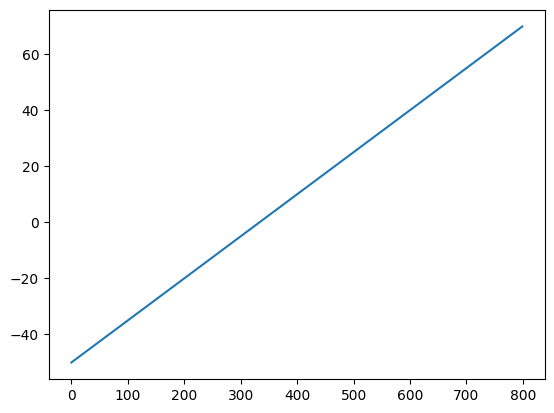

In [38]:
plt.close("all")
df['x1'].plot()

<AxesSubplot: >

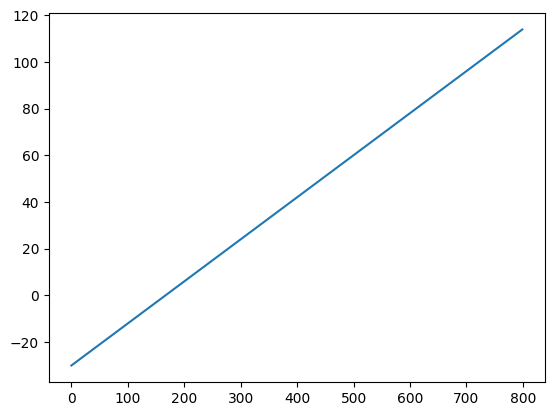

In [39]:
df['x2'].plot()

<AxesSubplot: >

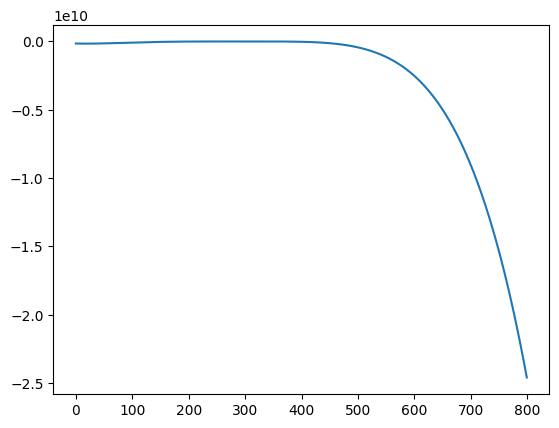

In [40]:
df['y'].plot()

<AxesSubplot: >

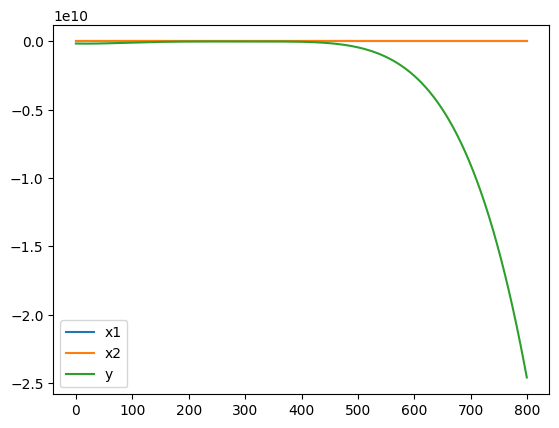

In [41]:
df.plot()

In [42]:

X = np.column_stack([
    x1**4,
    x2**4,
    x1**3 * x2,
    x1**5,
    x2**5,
    x1**3 * x2**2,
 ])


In [43]:
print(X[:5])

[[ 6.25000000e+06  8.10000000e+05  3.75000000e+06 -3.12500000e+08
  -2.43000000e+07 -1.12500000e+08]
 [ 6.17526242e+06  7.90715150e+05  3.69399734e+06 -3.07835905e+08
  -2.35789833e+07 -1.10154335e+08]
 [ 6.10119715e+06  7.71776724e+05  3.63859914e+06 -3.03227666e+08
  -2.28751840e+07 -1.07846767e+08]
 [ 6.02780012e+06  7.53180549e+05  3.58380116e+06 -2.98674781e+08
  -2.21882918e+07 -1.05576845e+08]
 [ 5.95506732e+06  7.34922475e+05  3.52959917e+06 -2.94176749e+08
  -2.15180004e+07 -1.03344120e+08]]


In [44]:
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

In [45]:
model = Ridge(alpha=1)
# model = RANSACRegressor(estimator=Ridge(alpha=1), random_state=42,min_samples=50)

In [46]:
# Define k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=25)


In [47]:
# Custom scoring functions
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

In [48]:
# poly = PolynomialFeatures(degree=(2,5), include_bias=True, interaction_only=False)
# X = poly.fit_transform(X)

In [49]:
# Run CV
mse_scores = cross_val_score(model, X, y, cv=kf, scoring=mse_scorer)
r2_scores = cross_val_score(model, X, y, cv=kf, scoring=r2_scorer)

/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=3.33571e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=5.72477e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=3.33571e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=5.72477e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True

In [50]:
print("=== Ridge Regression with 5-Fold CV ===")
print("MSE per fold:", -mse_scores)
print("Mean MSE:", -mse_scores.mean())


=== Ridge Regression with 5-Fold CV ===
MSE per fold: [4.41241799 3.85164779 4.25799496 3.18480088 3.80574107]
Mean MSE: 3.9025205375150804


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.112, random_state=12)
model.fit(X_train, y_train,)
y_pred = model.predict(X_test)
print("=== Linear Features ===")
print("MSE:", mean_squared_error(y_test, y_pred))

=== Linear Features ===
MSE: 3.9999173557047842


/home/suhaib/miniconda3/envs/Ditto/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.86382e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.112, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("=== Linear Features ===")
print("MSE:", mean_squared_error(y_test, y_pred))

=== Linear Features ===
MSE: 3.4017129033335576


In [53]:

# poly = PolynomialFeatures(degree=(2,5), include_bias=True, interaction_only=False)
# X_train_poly = poly.fit_transform(X_train)
# X_test_poly = poly.transform(X_test)

In [54]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [55]:
model.coef_

array([ 17.77853399,  20.13425909, -21.60282148,   2.34549529,
        -0.5555679 ,  -4.67990595])

In [56]:
model.intercept_

-3375446.7962961197

In [57]:
print("=== Linear Features ===")
print("MSE:", mean_squared_error(y_test, y_pred))

=== Linear Features ===
MSE: 3.4017129033335576


(90,)


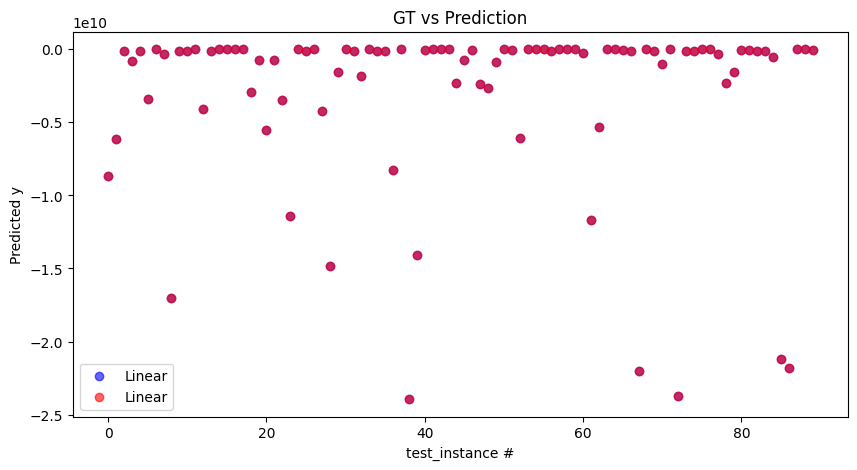

In [58]:
plt.figure(figsize=(10,5))
print(y_test.shape)
plt.scatter(np.arange(y_test.shape[0]),y_test, label="Linear", alpha=0.6, color='b')
plt.scatter(np.arange(y_test.shape[0]),y_pred, label="Linear", alpha=0.6,color='r')
plt.xlabel("test_instance #")
plt.ylabel("Predicted y")
plt.legend()
plt.title("GT vs Prediction")
plt.show()

In [59]:
df_test = pd.read_csv("./find-polynomial/test.csv")
df_test.head()

,x1,x2
0,70.120120,114.144144
1,70.270270,114.324324
2,70.420420,114.504505
3,70.570571,114.684685
4,70.720721,114.864865


In [60]:
test_features=df_test[["x1","x2"]]

In [61]:
x1f = test_features["x1"].values
x2f = test_features["x2"].values

X_test_f = np.column_stack([
    x1f**4,
    x2f**4,
    x1f**3 * x2f,
    x1f**5,
    x2f**5,
    x1f**3 * x2f**2,
 ])

# X_test_f = poly.transform(test_features)

In [62]:
y_test_f = model.predict(X_test_f)

In [63]:
submission = pd.DataFrame(np.vstack([np.arange(200),y_test_f]).T,columns=["id","y"])
submission[["id"]] = submission[["id"]].astype(int)
submission.to_csv('./submission1.csv', index=False)

In [64]:
# submission = pd.DataFrame(np.vstack([np.arange(200),y_test_f]).T,columns=["id","y"])
# submission[["id"]] = submission[["id"]].astype(int)

In [65]:
# submission

In [66]:
# submission.to_csv('./find-polynomial/submission.csv', index=False) 